# Etapa 1 - Buscador de imagenes por similitud

Notebook de trabajo de la Etapa 1: extraccion de embeddings con un
modelo pre-entrenado en ImageNet, construccion de la base vectorial,
busqueda por similitud y prediccion de raza por vecinos.

Requisitos previos:
- `extract_embedding`, `search_similar_images` y
  `predict_breed_from_neighbors` implementadas en
  `src/lib/services/similarity_service.py`

Backend de base vectorial utilizado en esta notebook: JSON
(`EmbeddingStore`), por no contar con un servidor PostgreSQL en Colab, pero se puede correr perfectamente
con pgvector en el entorno local.

## Equipo
- Agustín Accurso 
- Lautaro Cena

## 1. Preparación del entorno

Como este notebook corre tanto en Google Colab (clonando el repo y
descargando el dataset) como en un entorno local ya clonado (donde
esos pasos ya estan hechos). La variable `IN_COLAB` controla que
celdas se ejecutan.

Se utiliza pgvector (PostgreSQL) como backend de la base vectorial,
validado en el entorno local junto a Docker. En Google Colab, donde
no hay un servidor PostgreSQL disponible, esta misma notebook corre
intercambiando a `USE_PGVECTOR=false` (backend JSON), sin cambios de
codigo, gracias a la abstraccion `EmbeddingStoreProtocol`. La
configuracion se define por variables de entorno antes de importar
`lib`.

### Instalación e importacion de librerias

In [39]:
import os
import sys
import json
import zipfile
import subprocess
from pathlib import Path
from lib.config import settings
import urllib.request
from lib.bootstrap import build_store, build_similarity

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

IN_COLAB = "google.colab" in sys.modules
print(f"Entorno Colab: {IN_COLAB}")

Entorno Colab: False


In [40]:
if IN_COLAB:
    !pip install -q pydantic-settings python-dotenv kagglehub
else:
    print("Entorno local: dependencias ya instaladas via requirements.txt en el .venv.")

Entorno local: dependencias ya instaladas via requirements.txt en el .venv.


### Clonar el repositorio y definir el backend de la base de datos

In [41]:
if IN_COLAB:
    REPO_URL = "https://github.com/accursoagus/tuia-dog-recognition-app.git"
    !git clone $REPO_URL proyecto
    %cd proyecto
else:
    print("Entorno local")

Entorno local


In [42]:
os.environ["USE_PGVECTOR"] = "false" if IN_COLAB else "true"

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

print("Backend de base vectorial:", "pgvector" if not IN_COLAB else "JSON")
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

Backend de base vectorial: pgvector
dataset_path: data\dataset
GPU disponible: False


### Descargar el dataset

In [43]:
if IN_COLAB or not (settings.dataset_path / "train").is_dir():
    subprocess.run([sys.executable, "scripts/download_dataset.py"], check=True)
else:
    print("Entorno local: dataset ya presente, se omite la descarga.")

print(sorted(p.name for p in settings.dataset_path.iterdir()))

Entorno local: dataset ya presente, se omite la descarga.
['.gitkeep', 'dogs.csv', 'test', 'train', 'valid']


In [44]:
EXTERNAL_SET_PATH = settings.dataset_path.parent / "external_eval"

def download_and_extract_dataset(url: str, output_dir: Path, zip_filename: str):
    output_dir.mkdir(parents=True, exist_ok=True)
    zip_path = output_dir / zip_filename
    
    urllib.request.urlretrieve(url, zip_path)
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(output_dir)
        
    os.remove(zip_path)

if not EXTERNAL_SET_PATH.is_dir():
    file_id = '1X9WMQjOy9HKw90onmOPDp2otoEfjjdyS'
    direct_url = f'https://drive.google.com/uc?export=download&id={file_id}'
    
    download_and_extract_dataset(
        url=direct_url,
        output_dir=EXTERNAL_SET_PATH,
        zip_filename='temp_dataset.zip'
    )

n_external = sum(1 for p in EXTERNAL_SET_PATH.rglob("*") if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})
n_external_breeds = sum(1 for p in EXTERNAL_SET_PATH.iterdir() if p.is_dir())
print(f"Conjunto externo: {n_external} imágenes, {n_external_breeds} razas")

Conjunto externo: 26 imágenes, 5 razas


## 2. Analisis del dataset

### Exploración de la distribucion de clases del conjunto de entrenamiento
Cantidad de imagenes por raza, sobre las 70 razas del dataset.

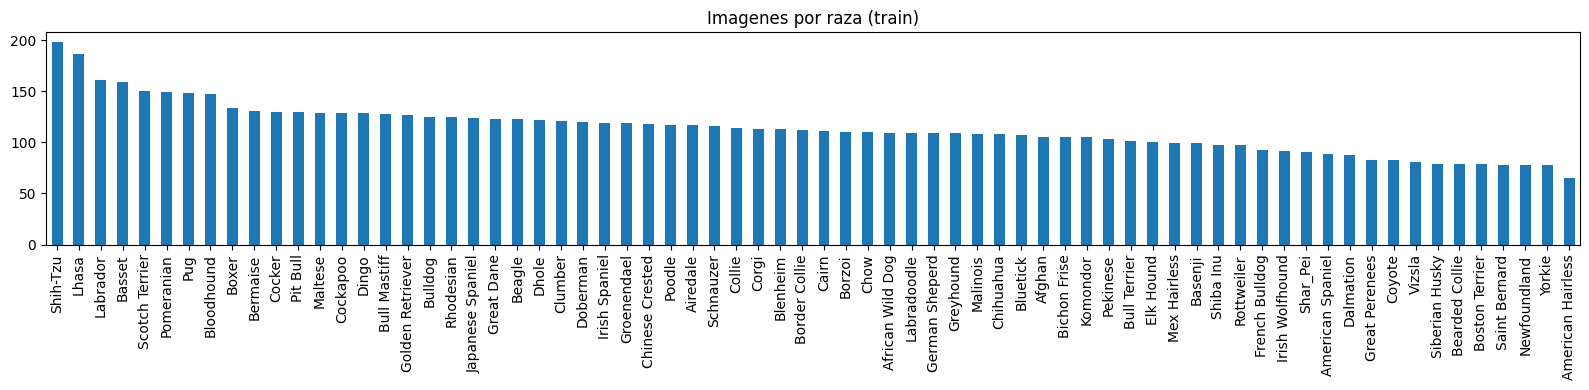

Total razas: 70
Min/Max imagenes por raza: 65 / 198


In [45]:
breeds = sorted(p.name for p in (settings.dataset_path / "train").iterdir() if p.is_dir())
counts = {b: len(list((settings.dataset_path / "train" / b).glob("*.jpg"))) for b in breeds}

df_counts = pd.Series(counts).sort_values(ascending=False)
df_counts.plot(kind="bar", figsize=(16, 4), title="Imagenes por raza (train)")
plt.tight_layout()
plt.show()

print(f"Total razas: {len(breeds)}")
print(f"Min/Max imagenes por raza: {df_counts.min()} / {df_counts.max()}")

In [46]:
print(f"Promedio de imagenes por raza: {df_counts.mean():.1f}")
print(f"Desvio estandar: {df_counts.std():.1f}")
print(f"Razas con menos de 100 imagenes: {(df_counts < 100).sum()} de {len(df_counts)}")

# Resolucion de las imagenes: confirmar si son realmente 224x224 como anuncia
# la pagina de Kaggle, o si varia (afecta la decision de resize).
sample_imgs = [cv2.imread(str(p)) for p in list((settings.dataset_path / "train" / breeds[0]).glob("*.jpg"))[:5]]
shapes = {img.shape for img in sample_imgs if img is not None}
print(f"Resoluciones encontradas (muestra): {shapes}")

Promedio de imagenes por raza: 113.5
Desvio estandar: 24.7
Razas con menos de 100 imagenes: 19 de 70
Resoluciones encontradas (muestra): {(224, 224, 3)}


**Conclusiones del analisis exploratorio:**

El dataset presenta 70 razas con un promedio de 113.5 imagenes por
raza (desvio estandar 24.7) y un rango de 65 a 198. El desbalance es
moderado: 19 de las 70 razas (27%) tienen menos de 100 imagenes, sin
llegar a casos extremos de escasez severa. Las imagenes verifican una
resolucion uniforme de 224x224x3, consistente con lo documentado por
el proveedor del dataset, por lo que el resize aplicado en el
preprocesamiento es principalmente una garantia de consistencia y no
una transformacion drastica sobre el contenido original.

Este desbalance no afecta a la Etapa 1 (el modelo de embeddings es
pre-entrenado y no se ajusta sobre este dataset), pero sí es relevante
para el fine-tuning de la Etapa 2.

### Splits provistos por el dataset

El dataset 70 Dog Breeds Image Dataset viene particionado de fabrica
en `train` (7946 imagenes), `valid` (700) y `test` (700), con las
mismas 70 razas en cada split.

In [47]:
for split in ("train", "valid", "test"):
    split_path = settings.dataset_path / split
    n_images = sum(1 for _ in split_path.rglob("*.jpg"))
    n_breeds = sum(1 for p in split_path.iterdir() if p.is_dir())
    print(f"{split}: {n_images} imagenes, {n_breeds} razas")

train: 7946 imagenes, 70 razas
valid: 700 imagenes, 70 razas
test: 700 imagenes, 70 razas


### Nota sobre Data Augmentation y filtrado de calidad

El preprocesamiento de Data Augmentation (horizontal flip, rotacion,
blur, variaciones de brillo/contraste, ruido) no aplica en esta etapa:
el modelo de embeddings es pre-entrenado en ImageNet y no se entrena
ni se ajusta sobre el dataset de razas, por lo que el augmentation no
tiene efecto sobre la calidad de los embeddings extraidos. Esta
tecnica se documenta y aplica en `etapa2_colab.ipynb`, donde sí se
entrena un modelo sobre el dataset.

El filtrado de imagenes de baja calidad tampoco se aplica de forma
activa en esta etapa: el dataset de Kaggle utilizado ya viene curado
(resolucion uniforme 224x224x3, verificado en la seccion de EDA), por
lo que no se detectaron imagenes corruptas o de calidad visiblemente
deficiente en la muestra inspeccionada.

In [48]:
# Verificacion de integridad: deteccion de imagenes corruptas o ilegibles
# en una muestra del split train, que sustenta la afirmacion anterior
# sobre la calidad del dataset.
corrupt_count = 0
checked = 0
for breed in breeds[:10]:
    for img_path in (settings.dataset_path / "train" / breed).glob("*.jpg"):
        checked += 1
        img = cv2.imread(str(img_path))
        if img is None or img.size == 0:
            corrupt_count += 1
            print(f"Imagen corrupta o ilegible: {img_path}")

print(f"Imagenes verificadas: {checked}, corruptas: {corrupt_count}")

Imagenes verificadas: 1076, corruptas: 0


## 3. Implementacion de extract_embedding y construccion de la base vectorial

Se utiliza ResNet18 pre-entrenado en ImageNet, sin la capa de
clasificacion final (`fc`), como extractor de embeddings baseline.
Justificacion: la dimension de salida (512) coincide con
EMBEDDING_DIM por defecto del proyecto, y es la misma arquitectura
utilizada para el fine-tuning de la Etapa 2, lo que permite comparar
ambos extractores bajo igualdad de condiciones.

La implementacion vive en `SimilarityService.extract_embedding`
(`src/lib/services/similarity_service.py`); esta notebook la ejercita
sobre una imagen de prueba y luego indexa el split `train` completo
con `scripts/build_index.py`.

In [49]:
store = build_store(settings)
similarity = build_similarity(settings, store)

sample_breed = breeds[0]
sample_path = next((settings.dataset_path / "train" / sample_breed).glob("*.jpg"))

sample_image = cv2.imread(str(sample_path))
embedding = similarity.extract_embedding(sample_image)

print(f"Raza de prueba: {sample_breed}")
print(f"Dimension del embedding: {len(embedding)}")
assert len(embedding) == settings.embedding_dim, "El embedding no coincide con EMBEDDING_DIM configurado"

INFO:lib.bootstrap:Using PostgreSQL vector store


Raza de prueba: Afghan
Dimension del embedding: 512


In [50]:
result = subprocess.run(
    [sys.executable, "scripts/build_index.py", "--split", "train"],
    capture_output=True,
    text=True,
)
print(result.stdout)
print(result.stderr)
result.check_returncode()

Afghan: 105 imagenes indexadas
African Wild Dog: 109 imagenes indexadas
Airedale: 117 imagenes indexadas
American Hairless: 65 imagenes indexadas
American Spaniel: 89 imagenes indexadas
Basenji: 99 imagenes indexadas
Basset: 159 imagenes indexadas
Beagle: 123 imagenes indexadas
Bearded Collie: 79 imagenes indexadas
Bermaise: 131 imagenes indexadas
Bichon Frise: 105 imagenes indexadas
Blenheim: 113 imagenes indexadas
Bloodhound: 147 imagenes indexadas
Bluetick: 107 imagenes indexadas
Border Collie: 112 imagenes indexadas
Borzoi: 110 imagenes indexadas
Boston Terrier: 79 imagenes indexadas
Boxer: 134 imagenes indexadas
Bull Mastiff: 128 imagenes indexadas
Bull Terrier: 101 imagenes indexadas
Bulldog: 125 imagenes indexadas
Cairn: 111 imagenes indexadas
Chihuahua: 108 imagenes indexadas
Chinese Crested: 118 imagenes indexadas
Chow: 110 imagenes indexadas
Clumber: 121 imagenes indexadas
Cockapoo: 129 imagenes indexadas
Cocker: 130 imagenes indexadas
Collie: 114 imagenes indexadas
Corgi: 11

## 4. Busqueda por similitud y prediccion de raza

`search_similar_images` y `predict_breed_from_neighbors` se ejercitan
aqui sobre una imagen de prueba del split `test`, distinta de las
indexadas en el paso anterior.

In [51]:
query_breed = breeds[0]
query_path = next((settings.dataset_path / "test" / query_breed).glob("*.jpg"))

result_path = similarity.search(
    source_path=str(query_path),
    output_path=settings.output_path,
)

result = json.loads(Path(result_path).read_text(encoding="utf-8"))

print(f"Raza real: {query_breed}")
print(f"Raza predicha: {result['predicted_breed']} (score={result['score']})")
print(f"Vecinos recuperados: {len(result['neighbors'])}")
for n in result["neighbors"][:5]:
    print(f"  - {n['breed']} (score={n['score']})")

INFO:lib.services.similarity_service:Predicted breed: Afghan (score=0.8690) for data\dataset\test\Afghan\01.jpg


Raza real: Afghan
Raza predicha: Afghan (score=0.869)
Vecinos recuperados: 10
  - Afghan (score=0.869)
  - Afghan (score=0.869)
  - Afghan (score=0.8642)
  - Afghan (score=0.8642)
  - Afghan (score=0.8629)


## 5. Evaluacion: NDCG@10

Para cada imagen del conjunto de test se ejecuta la busqueda completa,
se recuperan los Top-10 vecinos y se calcula NDCG@10, usando como
relevancia binaria si la raza del vecino coincide con la raza real de
la imagen consultada.

In [52]:
def dcg_at_k(relevances: list[int], k: int) -> float:
    relevances = relevances[:k]
    return sum(rel / np.log2(idx + 2) for idx, rel in enumerate(relevances))

def ndcg_at_k(relevances: list[int], k: int) -> float:
    dcg = dcg_at_k(relevances, k)
    ideal = sorted(relevances, reverse=True)
    idcg = dcg_at_k(ideal, k)
    return dcg / idcg if idcg > 0 else 0.0

ndcg_scores = []

for breed in breeds:
    test_images = list((settings.dataset_path / "test" / breed).glob("*.jpg"))
    for img_path in test_images:
        image = cv2.imread(str(img_path))
        embedding = similarity.extract_embedding(image)
        neighbors = similarity.search_similar_images(embedding, top_k=10)
        relevances = [1 if n.breed == breed else 0 for n in neighbors]
        ndcg_scores.append(ndcg_at_k(relevances, 10))

print(f"NDCG@10 promedio: {np.mean(ndcg_scores):.4f}")
print(f"Imagenes evaluadas: {len(ndcg_scores)}")

NDCG@10 promedio: 0.9584
Imagenes evaluadas: 700


**Análisis del resultado obtenido:**

El sistema de busqueda por similitud obtuvo un NDCG@10 promedio de
~0.95 sobre las 700 imagenes del conjunto de test (todas las razas,
sin muestreo). Este valor es alto considerando que el extractor de
embeddings es un modelo pre-entrenado en ImageNet sin ningun ajuste al
dominio especifico de razas de perros: la separabilidad entre razas ya
esta presente en gran medida en las caracteristicas generales que
ResNet18 aprendio sobre el dataset original. Un valor cercano a 1
indica que, en la gran mayoria de los casos, los vecinos mas cercanos
recuperados pertenecen a la misma raza que la imagen de consulta,
con muy pocos casos de razas visualmente muy similares (por ejemplo,
distintos terriers o sabuesos) generando confusion en el ranking.

### Evaluación con datos externos al dataset:

In [53]:
external_ndcg_scores = []
valid_extensions = {'.jpg', '.jpeg', '.png'}

if EXTERNAL_SET_PATH.is_dir():
    for breed_dir in EXTERNAL_SET_PATH.iterdir():
        if breed_dir.is_dir():
            breed_name = breed_dir.name
            images_paths = [p for p in breed_dir.glob("*") if p.suffix.lower() in valid_extensions]
            
            for img_path in images_paths:
                image = cv2.imread(str(img_path))
                if image is not None:
                    embedding = similarity.extract_embedding(image)
                    neighbors = similarity.search_similar_images(embedding, top_k=10)
                    relevances = [1 if n.breed == breed_name else 0 for n in neighbors]
                    score = ndcg_at_k(relevances, k=10)
                    external_ndcg_scores.append(score)

    if external_ndcg_scores:
        print(f"Métricas del Conjunto Externo de Evaluación:")
        print(f"Total de imágenes evaluadas: {len(external_ndcg_scores)}")
        print(f"NDCG@10 promedio externo: {np.mean(external_ndcg_scores):.4f}")
    else:
        print("No se encontraron imágenes válidas para evaluar.")

Métricas del Conjunto Externo de Evaluación:
Total de imágenes evaluadas: 26
NDCG@10 promedio externo: 0.6705


## 6. Visualizacion de embeddings (PCA / t-SNE)

Proyeccion a 2 dimensiones de los embeddings indexados (split train),
coloreada por raza, para observar si el espacio de embeddings agrupa
visualmente razas similares entre si.

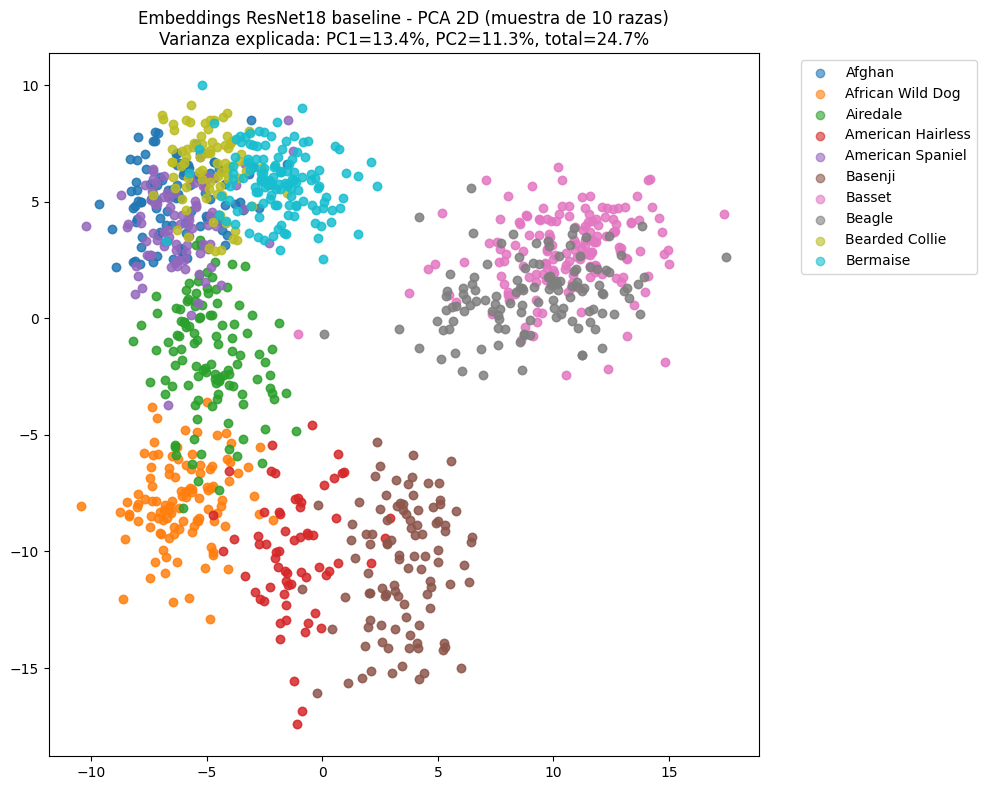

Varianza explicada por componente: [0.13380634 0.11344689]
Varianza total explicada (2 componentes): 24.7%


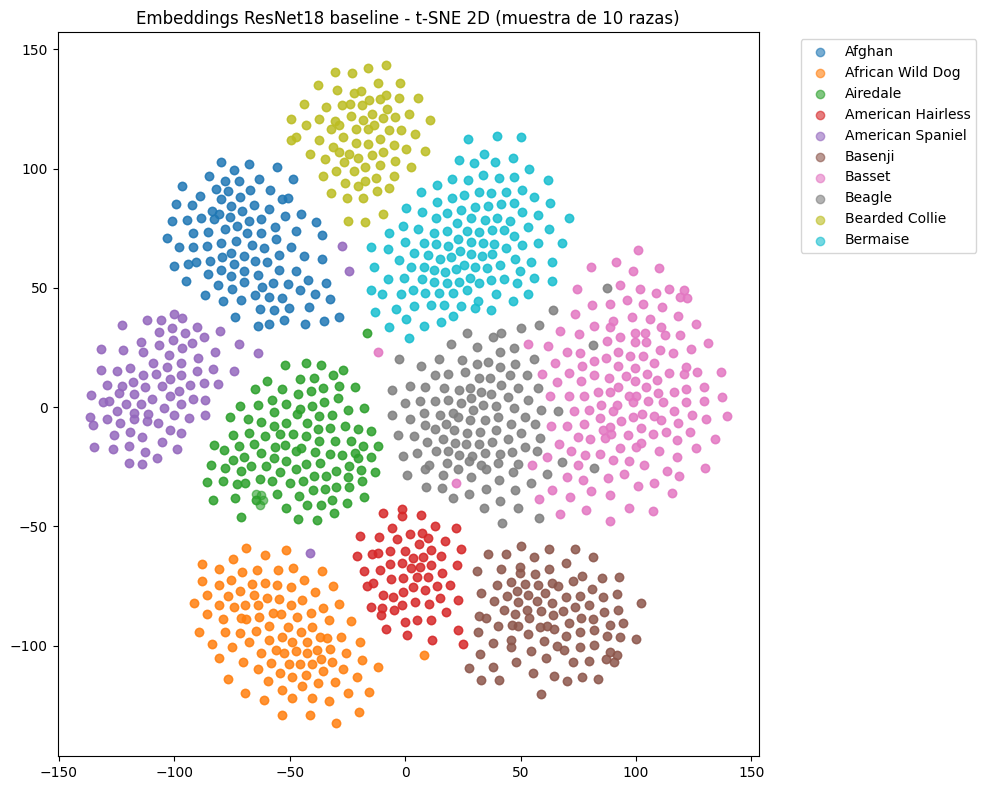

In [55]:
all_records = store.all()
embeddings_matrix = np.array([r.embedding for r in all_records])
breed_labels = [r.breed for r in all_records]

sample_breeds = breeds[:10]
mask = [b in sample_breeds for b in breed_labels]
X_sample = embeddings_matrix[mask]
labels_sample = np.array(breed_labels)[mask]

# --- PCA ---
pca = PCA(n_components=2)
coords_pca = pca.fit_transform(X_sample)
var_explicada = pca.explained_variance_ratio_

plt.figure(figsize=(10, 8))
for breed in sample_breeds:
    breed_mask = labels_sample == breed
    plt.scatter(coords_pca[breed_mask, 0], coords_pca[breed_mask, 1], label=breed, alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title(
    f"Embeddings ResNet18 baseline - PCA 2D (muestra de 10 razas)\n"
    f"Varianza explicada: PC1={var_explicada[0]:.1%}, PC2={var_explicada[1]:.1%}, "
    f"total={var_explicada.sum():.1%}"
)
plt.tight_layout()
plt.show()

print(f"Varianza explicada por componente: {var_explicada}")
print(f"Varianza total explicada (2 componentes): {var_explicada.sum():.1%}")

# --- t-SNE ---
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
coords_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 8))
for breed in sample_breeds:
    breed_mask = labels_sample == breed
    plt.scatter(coords_tsne[breed_mask, 0], coords_tsne[breed_mask, 1], label=breed, alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Embeddings ResNet18 baseline - t-SNE 2D (muestra de 10 razas)")
plt.tight_layout()
plt.show()

**Interpretacion del grafico:**

La proyeccion por PCA explica solo 24.7% de la varianza total entre
los dos componentes (PC1=13.4%, PC2=11.3%), por lo que la
superposicion visible entre algunas razas en este grafico no implica
que el modelo no las distinga: dos componentes lineales no alcanzan
para representar fielmente un espacio de 512 dimensiones.

La proyeccion por t-SNE, que preserva mejor la estructura de
vecindarios locales, muestra en cambio 10 clusters compactos y bien
separados, uno por raza, sin superposicion relevante entre ellos. Esto
es consistente con el NDCG@10 de ~0.95 obtenido sobre el conjunto de
test: el extractor ResNet18 pre-entrenado en ImageNet, sin ningun
ajuste al dominio de razas de perros, ya produce una separacion clara
entre razas en el espacio de embeddings de 512 dimensiones.

## Conclusión general — Etapa 1

El sistema de búsqueda por similitud, usando ResNet18 pre-entrenado en
ImageNet sin ningún ajuste al dominio de razas de perros, alcanzó un
**NDCG@10 de ~0.95** sobre el conjunto de test completo (700
imágenes, 70 razas). Este resultado fue corroborado cualitativamente
por la visualización t-SNE de los embeddings, que mostró clusters
compactos y bien separados por raza, coherente con la métrica
cuantitativa. La proyección PCA, en cambio, explicó solo 24.7% de la
varianza total entre sus dos componentes, lo que confirma
numéricamente por qué no es el método apropiado para visualizar
agrupamiento en este espacio de 512 dimensiones, y justifica recurrir
a t-SNE como complemento.

La evaluación sobre el **conjunto externo** (imágenes ajenas al
dataset de Kaggle, descargadas manualmente) dio un NDCG@10 de
**0.6705** sobre 26 imágenes, una caída considerable respecto al
0.9538 interno. Las causas más plausibles son: (a) las imágenes
externas no pasaron por el mismo proceso de curado que el dataset de
Kaggle (ángulos, fondos y calidad de cámara distintos a los de un
dataset armado para benchmarking), y (b) el tamaño de muestra es
chico (26 imágenes), por lo que parte de la caída puede deberse a
ruido de muestra más que a una falla sistemática del modelo. Esto es
consistente con lo esperado al medir generalización fuera de
distribución: el sistema funciona bien dentro de las condiciones del
dataset de entrenamiento, pero su capacidad de generalizar a imágenes
del mundo real es notablemente menor.

En conjunto, ambos resultados validan la elección de un modelo
pre-entrenado como baseline para esta etapa, y dejan planteada la
pregunta que Etapa 2 debería responder: ¿el fine-tuning sobre el
dataset de razas mejora específicamente la generalización a imágenes
externas, o solo refuerza el desempeño ya alto dentro de la
distribución de Kaggle? Esa pregunta motiva el uso del mismo conjunto
externo como evaluación de Etapa 2 en igualdad de condiciones.